# Chest X-Ray Classification using Original XGBoost

This experiment uses XGBoost directly on preprocessed chest X-ray images.
The objective is to classify images into Normal and Pneumonia classes and compare the performance with CNN and SVM approaches.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

print("Libraries imported successfully.")

Libraries imported successfully.


## Dataset Loading and Preprocessing

The Chest X-Ray dataset is loaded from the training and testing folders.
Images are converted to grayscale, resized to a fixed size, normalized, and prepared for XGBoost classification.

In [3]:
train_normal_path = "/mnt/c/ML Projects/Medical-Image-Classification-Projects/Exersize-2(ChestXRay)/archive/chest_xray/train/NORMAL"
train_pneumonia_path = "/mnt/c/ML Projects/Medical-Image-Classification-Projects/Exersize-2(ChestXRay)/archive/chest_xray/train/PNEUMONIA"

test_normal_path = "/mnt/c/ML Projects/Medical-Image-Classification-Projects/Exersize-2(ChestXRay)/archive/chest_xray/test/NORMAL"
test_pneumonia_path = "/mnt/c/ML Projects/Medical-Image-Classification-Projects/Exersize-2(ChestXRay)/archive/chest_xray/test/PNEUMONIA"

print("Dataset paths loaded successfully.")

Dataset paths loaded successfully.


## Image Loading

Images are loaded from the dataset folders, converted to grayscale,
resized to 200×200 pixels, flattened into feature vectors, and assigned labels.

Label Encoding:

- 0 → Normal
- 1 → Pneumonia

In [4]:
def load_images(folder_path, label):

    images = []
    labels = []

    for file in os.listdir(folder_path):

        image_path = os.path.join(folder_path, file)

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            continue

        image = cv2.resize(image, (200, 200))

        images.append(image)
        labels.append(label)

    return images, labels

In [5]:
normal_train_images, normal_train_labels = load_images(
    train_normal_path,
    0
)

pneumonia_train_images, pneumonia_train_labels = load_images(
    train_pneumonia_path,
    1
)

normal_test_images, normal_test_labels = load_images(
    test_normal_path,
    0
)

pneumonia_test_images, pneumonia_test_labels = load_images(
    test_pneumonia_path,
    1
)

print("Images loaded successfully.")

Images loaded successfully.


## Dataset Creation

The Normal and Pneumonia images are combined into a single dataset.
Labels are assigned as:

- 0 → Normal
- 1 → Pneumonia

The resulting dataset is then converted into NumPy arrays for further processing.

In [6]:
xtrain = np.array(
    normal_train_images + pneumonia_train_images
)

ytrain = np.array(
    normal_train_labels + pneumonia_train_labels
)

xtest = np.array(
    normal_test_images + pneumonia_test_images
)

ytest = np.array(
    normal_test_labels + pneumonia_test_labels
)

print("Training Dataset Shape:", xtrain.shape)
print("Training Labels Shape :", ytrain.shape)

print("Testing Dataset Shape :", xtest.shape)
print("Testing Labels Shape  :", ytest.shape)

Training Dataset Shape: (5216, 200, 200)
Training Labels Shape : (5216,)
Testing Dataset Shape : (624, 200, 200)
Testing Labels Shape  : (624,)


## Feature Preparation

XGBoost requires a two-dimensional feature matrix.

Each image is therefore:

1. Flattened from 200 × 200 pixels into a single feature vector.
2. Converted to floating-point format.
3. Normalized to the range [0,1].

The resulting feature matrix is used as input to the XGBoost classifier.

In [7]:
xtrain = xtrain.reshape(
    xtrain.shape[0],
    -1
)

xtest = xtest.reshape(
    xtest.shape[0],
    -1
)

xtrain = xtrain.astype("float32") / 255.0
xtest = xtest.astype("float32") / 255.0

print("Training Feature Shape:", xtrain.shape)
print("Testing Feature Shape :", xtest.shape)

Training Feature Shape: (5216, 40000)
Testing Feature Shape : (624, 40000)


## Feature Preparation

XGBoost requires a two-dimensional feature matrix.

Each image is therefore:

1. Flattened from 200 × 200 pixels into a single feature vector.
2. Converted to floating-point format.
3. Normalized to the range [0,1].

The resulting feature matrix is used as input to the XGBoost classifier.

In [8]:
xtrain = xtrain.reshape(
    xtrain.shape[0],
    -1
)

xtest = xtest.reshape(
    xtest.shape[0],
    -1
)

xtrain = xtrain.astype("float32") / 255.0
xtest = xtest.astype("float32") / 255.0

print("Training Feature Shape:", xtrain.shape)
print("Testing Feature Shape :", xtest.shape)

Training Feature Shape: (5216, 40000)
Testing Feature Shape : (624, 40000)


## XGBoost Model Training

The flattened and normalized image features are used to train an XGBoost classifier.

XGBoost builds an ensemble of decision trees sequentially, where each new tree attempts to correct the errors made by previous trees.

In [9]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(xtrain, ytrain)

print("XGBoost training completed.")

XGBoost training completed.


In [10]:
ytrain_pred = xgb_model.predict(xtrain)
ytest_pred = xgb_model.predict(xtest)

train_accuracy = accuracy_score(ytrain, ytrain_pred)
test_accuracy = accuracy_score(ytest, ytest_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")

Training Accuracy: 1.0000
Testing Accuracy : 0.7388


## Model Evaluation

The trained XGBoost model is evaluated using training and testing accuracy.
A detailed classification report is generated to analyze precision, recall, and F1-score for each class.

In [11]:
print("\nClassification Report:\n")
print(classification_report(ytest, ytest_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.32      0.48       234
           1       0.71      0.99      0.83       390

    accuracy                           0.74       624
   macro avg       0.83      0.66      0.65       624
weighted avg       0.80      0.74      0.70       624



In [12]:
cm = confusion_matrix(ytest, ytest_pred)

print(cm)

[[ 75 159]
 [  4 386]]


## Confusion Matrix Visualization

The confusion matrix is visualized using a heatmap to better understand the classification behavior of the XGBoost model.

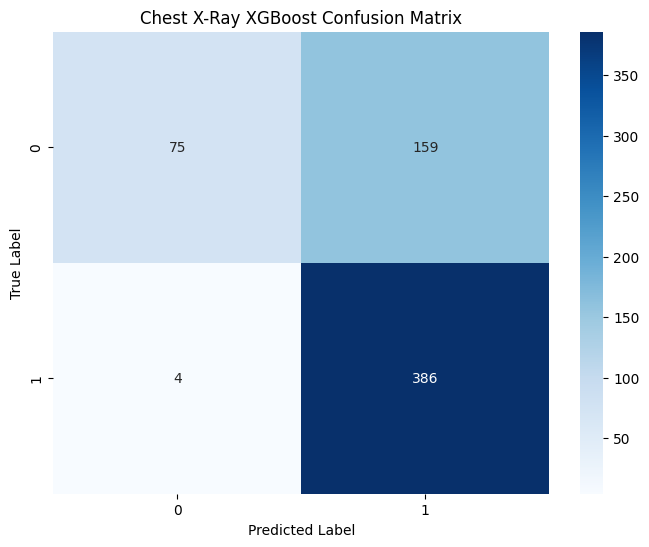

In [13]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Chest X-Ray XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Evaluation Metrics

The XGBoost model is evaluated using:

- Accuracy
- F1 Score
- Sensitivity (Recall)
- Specificity

These metrics provide a comprehensive assessment of classification performance on the Chest X-Ray dataset.

In [14]:
f1 = f1_score(ytest, ytest_pred, average="weighted")

sensitivity = recall_score(
    ytest,
    ytest_pred,
    average="weighted"
)

cm = confusion_matrix(ytest, ytest_pred)

specificity_list = []

for i in range(len(cm)):

    tp = cm[i, i]

    fn = np.sum(cm[i, :]) - tp

    fp = np.sum(cm[:, i]) - tp

    tn = np.sum(cm) - (tp + fn + fp)

    specificity = tn / (tn + fp)

    specificity_list.append(specificity)

specificity = np.mean(specificity_list)

print(f"Accuracy    : {test_accuracy*100:.2f}%")
print(f"F1 Score    : {f1*100:.2f}%")
print(f"Sensitivity : {sensitivity*100:.2f}%")
print(f"Specificity : {specificity*100:.2f}%")

Accuracy    : 73.88%
F1 Score    : 69.58%
Sensitivity : 73.88%
Specificity : 65.51%


## Training Percentage Experiment

The effect of training data size on model performance is analyzed.

The XGBoost model is trained using:

- 20% of training data
- 40% of training data
- 60% of training data
- 80% of training data

The resulting accuracies are compared to observe performance trends.

In [16]:
training_sizes = [0.2, 0.4, 0.6, 0.8]

xgb_train_scores = []
xgb_test_scores = []

for size in training_sizes:

    x_small, _, y_small, _ = train_test_split(
        xtrain,
        ytrain,
        train_size=size,
        random_state=10,
        stratify=ytrain
    )

    xgb_model = XGBClassifier(
        objective='binary:logistic',
        random_state=10,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1
    )

    xgb_model.fit(x_small, y_small)

    train_acc = xgb_model.score(x_small, y_small)
    test_acc = xgb_model.score(xtest, ytest)

    xgb_train_scores.append(train_acc)
    xgb_test_scores.append(test_acc)

    print(f"\nTraining Size: {int(size*100)}%")
    print(f"Samples Used: {len(x_small)}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy : {test_acc:.4f}")


Training Size: 20%
Samples Used: 1043
Training Accuracy: 1.0000
Testing Accuracy : 0.7212

Training Size: 40%
Samples Used: 2086
Training Accuracy: 1.0000
Testing Accuracy : 0.7292

Training Size: 60%
Samples Used: 3129
Training Accuracy: 1.0000
Testing Accuracy : 0.7324

Training Size: 80%
Samples Used: 4172
Training Accuracy: 1.0000
Testing Accuracy : 0.7340


## Accuracy Visualization

The testing accuracies obtained using different training percentages are plotted to visualize the impact of training data size on XGBoost performance.

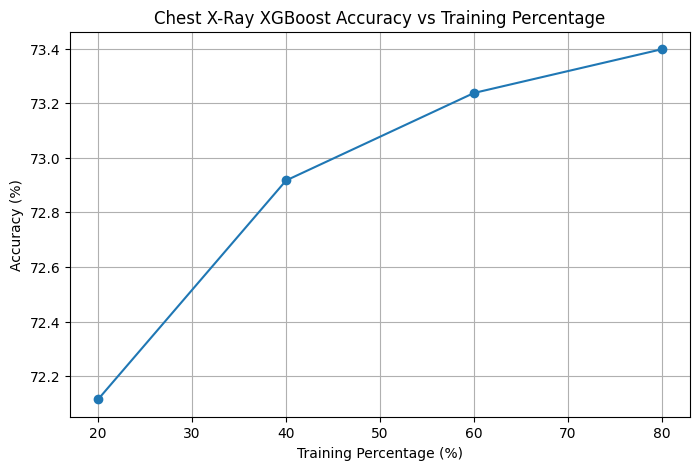

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    [20, 40, 60, 80],
    [x * 100 for x in xgb_test_scores],
    marker='o'
)

plt.title("Chest X-Ray XGBoost Accuracy vs Training Percentage")
plt.xlabel("Training Percentage (%)")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.show()